In [24]:
import h5py
from annbatch import DatasetCollection
import anndata as ad
from annbatch import Loader


DD_FILE = "/Users/selman/cellink_data/dummy_onek1k/dummy_onek1k.dd.h5"


In [26]:
def load_only_X_lazy(group):
    return ad.AnnData(
        X=ad.experimental.read_lazy(group["X"]),
        obs=ad.io.read_elem(group["obs"]),
        var=ad.io.read_elem(group["var"]),
    )

with h5py.File(DD_FILE, "r") as f:
    DatasetCollection("dd_C.zarr").add_adatas(
        [f["C"]],
        shuffle=True,
        load_adata=load_only_X_lazy,
        # set the params for sharding and shuffling with realistic datasets
    )
    DatasetCollection("dd_G.zarr").add_adatas(
        [f["G"]],
        shuffle=True,
        load_adata=load_only_X_lazy,
        # set the params for sharding and shuffling with realistic datasets
    )


Creating dataset collection:   0%|          | 0/1 [00:00<?, ?it/s]/Users/selman/projects/cellink/.venv/lib/python3.12/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
Creating dataset collection:   0%|          | 0/1 [00:00<?, ?it/s]/Users/selman/projects/cellink/.venv/lib/python3.12/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
Creating dataset collection: 100%|██████████| 1/1 [00:00<00:00,  1.28it/s]


In [59]:
loader_C = Loader(
    return_index=True,
    shuffle=True,
    batch_size=4,
    # set values based on realistic datasets
).use_collection(DatasetCollection("dd_C.zarr"))
loader_G = Loader(
    return_index=True,
    shuffle=True,
    # batch_size=1
    # set values based on realistic datasets
).use_collection(DatasetCollection("dd_G.zarr"))

In [60]:
next(iter(loader_C))['obs']['donor_id'].unique()

array(['OneK1K_159', 'OneK1K_109', 'OneK1K_1037', 'OneK1K_604'],
      dtype=object)

## Training LIVI

### Key Architecture Parameters

| Parameter | Meaning |
|---|---|
| `z_dim` | Number of cell-state latent factors (the VAE bottleneck) |
| `n_dxc_factors` | Number of donor × cell-state interaction (DxC) factors |
| `n_persistent_factors` | Number of persistent (cell-state-independent) donor factors |
| `warmup_epochs_vae` | Epochs to train only the VAE before activating donor effects |
| `warmup_epochs_G` | Additional epochs to train only `V` before activating `DxC` |

### Training Schedule

LIVI uses a three-phase warm-up to stabilise training:
1. **VAE pre-training** (`warmup_epochs_vae` epochs): only the encoder and base decoder are updated — the model learns cell-state factors without interference from donor effects.
2. **V training** (`warmup_epochs_G` epochs): the VAE is frozen; only persistent donor effects `V` are trained.
3. **Full model** (remaining epochs): DxC interaction factors are activated alongside `V`.

### Basic Training

The parameters below are scaled down for demonstration. In practice, use `z_dim=15`, `n_dxc_factors=300–700`, `max_epochs=400–600`, and `warmup_epochs_vae=60–90`.

In [20]:
checkpoint_path = train_livi(
    dd_ct,
    output_dir="livi_basic_run",
    # Architecture
    z_dim=5,               # cell-state latent dimensions (use 15 in practice)
    n_dxc_factors=20,      # DxC factors (use 300–700 in practice)
    n_persistent_factors=3, # persistent donor factors (use 5 in practice)
    encoder_hidden_dims=[256, 128, 64],  # encoder MLP widths
    # Data
    layer_key=None,        # None → uses dd.C.X (must be raw counts)
    use_size_factor=True,  # normalise by per-cell library size
    # Training schedule
    warmup_epochs_vae=5,
    warmup_epochs_G=0,
    max_epochs=15,
    min_epochs=5,
    # Optimiser
    learning_rate=8e-4,
    l1_weight=1e-3,
    A_weight=1e-3,
    # DataLoader
    batch_size=512,
    num_workers=0,
    seed=42,
)

print(f"Best checkpoint: {checkpoint_path}")

[2026-05-21 14:08:25,460] INFO:cellink.tl.external._livi: Using device: cpu
[2026-05-21 14:08:32,327] INFO:lightning_fabric.utilities.seed: Seed set to 42
[2026-05-21 14:08:32,517] INFO:pytorch_lightning.utilities.rank_zero: GPU available: True (mps), used: False
[2026-05-21 14:08:32,517] INFO:pytorch_lightning.utilities.rank_zero: TPU available: False, using: 0 TPU cores
[2026-05-21 14:08:32,518] INFO:pytorch_lightning.utilities.rank_zero: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


/Users/selman/projects/cellink/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/Users/selman/projects/cellink/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type         ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ encoder      │ Encoder      │  8.8 M │ train │     0 │
│ 1 │ decoder      │ LIVI_Decoder │  988 K │ train │     0 │
│ 2 │ D_context    │ Embedding    │  2.0 K │ train │     0 │
│ 3 │ V_persistent │ Embedding    │    300 │ train │     0 │
│   │ other params │ n/a          │    100 │ n/a   │   n/a │
└───┴──────────────┴──────────────┴────────┴───────┴───────┘

Trainable params: 9.0 M                                                                                            
Non-trainable params: 786 K                                                                                        
Total params: 9.8 M                                                                                                
Total estimated model params size (MB): 39                                                                         
Modules in train mode: 20                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/Users/selman/projects/cellink/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

...

Training V: True

Training DxC: True

DxC decoder requires grad: True

[2026-05-21 14:09:44,611] INFO:pytorch_lightning.utilities.rank_zero: `Trainer.fit` stopped: `max_epochs=15` reached.


[2026-05-21 14:09:44,623] INFO:cellink.tl.external._livi: LIVI training complete. Best checkpoint: /Users/selman/projects/cellink/docs/tutorials/livi_basic_run/checkpoints/epoch=0005_hp_metric=13243.94531.ckpt
Best checkpoint: /Users/selman/projects/cellink/docs/tutorials/livi_basic_run/checkpoints/epoch=0005_hp_metric=13243.94531.ckpt


### Training with Batch Covariates

Technical covariates such as experimental pool or sequencing batch can be corrected for within LIVI via the `covariates_keys` parameter. Each key must be a categorical column in `dd.C.obs`. LIVI learns a per-gene additive correction for each category.

In [21]:
# Verify that the covariate columns exist in dd.C.obs
print("Available obs columns:", dd_ct.C.obs.columns.tolist())

# 'sex' is available in the dummy dataset
covariates = ["sex"]

checkpoint_with_covariates = train_livi(
    dd_ct,
    output_dir="livi_covariate_run",
    z_dim=5,
    n_dxc_factors=20,
    n_persistent_factors=3,
    covariates_keys=covariates,  # corrects for sex
    # covariates_dims is inferred from data if not provided
    layer_key=None,
    warmup_epochs_vae=5,
    max_epochs=15,
    batch_size=512,
    seed=42,
)

print(f"Best checkpoint (with covariates): {checkpoint_with_covariates}")

Available obs columns: ['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'donor_id', 'pool_number', 'predicted.celltype.l2', 'predicted.celltype.l2.score', 'age', 'organism_ontology_term_id', 'tissue_ontology_term_id', 'assay_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'is_primary_data', 'suspension_type', 'tissue_type', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid']
[2026-05-21 14:09:44,639] INFO:cellink.tl.external._livi: Using device: cpu
[2026-05-21 14:09:44,640] INFO:lightning_fabric.utilities.seed: Seed set to 42
[2026-05-21 14:09:44,693] INFO:pytorch_lightning.utilities.rank_zero: GPU available: True (mps), used: False
[2026-05-21 14:09:44,694] INFO:pytorch_lightning.utilities.rank_zero: TPU available: False, using: 0 TPU cores
[2026-05-21 14:09:44,6

/Users/selman/projects/cellink/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.


┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type         ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ encoder          │ Encoder      │ 17.6 M │ train │     0 │
│ 1 │ decoder          │ LIVI_Decoder │  988 K │ train │     0 │
│ 2 │ D_context        │ Embedding    │  2.0 K │ train │     0 │
│ 3 │ V_persistent     │ Embedding    │    300 │ train │     0 │
│ 4 │ covariate_effect │ Embedding    │ 68.1 K │ train │     0 │
│   │ other params     │ n/a          │    100 │ n/a   │   n/a │
└───┴──────────────────┴──────────────┴────────┴───────┴───────┘

Trainable params: 17.9 M                                                                                           
Non-trainable params: 786 K                                                                                        
Total params: 18.7 M                                                                                               
Total estimated model params size (MB): 74                                                                         
Modules in train mode: 21                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/Users/selman/projects/cellink/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

...

Training V: True

Training DxC: True

DxC decoder requires grad: True

[2026-05-21 14:10:57,368] INFO:pytorch_lightning.utilities.rank_zero: `Trainer.fit` stopped: `max_epochs=15` reached.


[2026-05-21 14:10:57,379] INFO:cellink.tl.external._livi: LIVI training complete. Best checkpoint: /Users/selman/projects/cellink/docs/tutorials/livi_covariate_run/checkpoints/epoch=0014_hp_metric=14859.14746.ckpt
Best checkpoint (with covariates): /Users/selman/projects/cellink/docs/tutorials/livi_covariate_run/checkpoints/epoch=0014_hp_metric=14859.14746.ckpt


### Training with Known cis-eQTLs (using `dd.G` genotypes)

This mode jointly uses `dd.C` (expression) and `dd.G` (genotypes) to correct for local genetic effects during training, preventing cis-genetic variance from leaking into the donor embeddings.

Required inputs:

| Input | Shape | Source |
|---|---|---|
| `eqtl_genotypes` | donors × cis-SNPs | `dd.G.X` — auto-extracted when DonorData is passed **and `dd.G` has been pre-filtered to cis-SNPs** |
| `known_cis_eqtls` | cis-SNPs × genes (binary 0/1) | External annotation (GTEx, eQTL Catalogue); only genes with known cis-eQTLs needed |
| `n_cis_snps` | int | Number of cis-SNPs; must equal `dd.G.n_vars` when auto-extracting |

**Auto-extraction pattern (recommended for real analyses):**
Pre-filter `dd.G` to cis-SNPs only, then pass DonorData — `eqtl_genotypes` is auto-extracted:
```python
dd_cis = dd_ct[:, :, cis_snp_mask, :]          # subset dd.G to cis-SNPs
train_livi(dd_cis, ..., n_cis_snps=dd_cis.G.n_vars, known_cis_eqtls=annotation_df)
```

Below we build a small synthetic `known_cis_eqtls` and extract `eqtl_genotypes` from `dd.G.X` explicitly (since we are using a SNP subset for speed). The cell runs end-to-end on the dummy dataset.

In [22]:
from anndata.utils import asarray

# Use a small subset of SNPs from dd.G for the demo (50 SNPs for speed)
# In a real analysis, dd.G would be pre-filtered to cis-SNPs and the
# eqtl_genotypes auto-extraction would be used instead.
n_demo_snps = 50
demo_snps = dd_ct.G.var_names[:n_demo_snps]

# eqtl_genotypes: donors × cis-SNPs, extracted from dd.G.X
eqtl_genotypes_demo = pd.DataFrame(
    asarray(dd_ct.G.X[:, :n_demo_snps]),
    index=dd_ct.G.obs_names,
    columns=demo_snps,
)

# known_cis_eqtls: cis-SNPs × genes, binary (0/1)
# Rows = SNP IDs (must match eqtl_genotypes columns)
# Columns = gene IDs with known cis-associations (LIVI fills 0 for all other genes)
# In practice: derive from GTEx, eQTL Catalogue, or similar reference
rng = np.random.default_rng(42)
target_genes = dd_ct.C.var_names[:200]   # only a subset of genes needed
known_cis_eqtls_demo = pd.DataFrame(
    0, index=demo_snps, columns=target_genes, dtype=int
)
for snp in demo_snps:                    # assign each SNP to ~5 random genes
    hits = rng.choice(target_genes, size=5, replace=False)
    known_cis_eqtls_demo.loc[snp, hits] = 1

print(f"eqtl_genotypes:   {eqtl_genotypes_demo.shape}  (donors × cis-SNPs)")
print(f"known_cis_eqtls:  {known_cis_eqtls_demo.shape}  (cis-SNPs × genes with known associations)")

checkpoint_cis = train_livi(
    dd_ct,
    output_dir="livi_cis_run",
    z_dim=5,
    n_dxc_factors=20,
    n_persistent_factors=3,
    n_cis_snps=n_demo_snps,
    known_cis_eqtls=known_cis_eqtls_demo,   # SNPs × genes binary annotation
    eqtl_genotypes=eqtl_genotypes_demo,      # donors × SNPs from dd.G.X
    layer_key=None,
    covariates_keys=["sex"],
    warmup_epochs_vae=5,
    warmup_epochs_G=0,
    max_epochs=15,
    min_epochs=5,
    batch_size=512,
    cell_state_cis=True,   # learn cell-state-specific cis corrections per SNP
    seed=42,
)

print(f"Best checkpoint (cis-eQTL mode): {checkpoint_cis}")

eqtl_genotypes:   (100, 50)  (donors × cis-SNPs)
known_cis_eqtls:  (50, 200)  (cis-SNPs × genes with known associations)
[2026-05-21 14:10:57,403] INFO:cellink.tl.external._livi: Using device: cpu
[2026-05-21 14:10:57,404] INFO:lightning_fabric.utilities.seed: Seed set to 42
[2026-05-21 14:10:57,528] INFO:pytorch_lightning.utilities.rank_zero: GPU available: True (mps), used: False
[2026-05-21 14:10:57,529] INFO:pytorch_lightning.utilities.rank_zero: TPU available: False, using: 0 TPU cores
[2026-05-21 14:10:57,529] INFO:pytorch_lightning.utilities.rank_zero: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


/Users/selman/projects/cellink/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.


┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type         ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ encoder          │ Encoder      │ 17.6 M │ train │     0 │
│ 1 │ decoder          │ LIVI_Decoder │  988 K │ train │     0 │
│ 2 │ D_context        │ Embedding    │  2.0 K │ train │     0 │
│ 3 │ V_persistent     │ Embedding    │    300 │ train │     0 │
│ 4 │ covariate_effect │ Embedding    │ 68.1 K │ train │     0 │
│   │ other params     │ n/a          │  8.5 M │ n/a   │   n/a │
└───┴──────────────────┴──────────────┴────────┴───────┴───────┘

Trainable params: 17.9 M                                                                                           
Non-trainable params: 9.3 M                                                                                        
Total params: 27.2 M                                                                                               
Total estimated model params size (MB): 108                                                                        
Modules in train mode: 21                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/Users/selman/projects/cellink/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

...

Training V: True

Training DxC: True

DxC decoder requires grad: True

[2026-05-21 14:12:37,573] INFO:pytorch_lightning.utilities.rank_zero: `Trainer.fit` stopped: `max_epochs=15` reached.


[2026-05-21 14:12:37,579] INFO:cellink.tl.external._livi: LIVI training complete. Best checkpoint: /Users/selman/projects/cellink/docs/tutorials/livi_cis_run/checkpoints/epoch=0014_hp_metric=14883.20703.ckpt
Best checkpoint (cis-eQTL mode): /Users/selman/projects/cellink/docs/tutorials/livi_cis_run/checkpoints/epoch=0014_hp_metric=14883.20703.ckpt


### Dry Run: Inspect Configuration Without Training

Pass `run=False` to print the resolved model dimensions and return `None` without running any training. This is useful for verifying that `x_dim` and `y_dim` are inferred correctly before launching a long job.

In [23]:
train_livi(
    dd_ct,
    output_dir="livi_dryrun",
    z_dim=15,
    n_dxc_factors=300,
    n_persistent_factors=5,
    covariates_keys=["sex"],
    max_epochs=400,
    run=False,  # inspect config only
)

[2026-05-21 14:12:37,595] INFO:cellink.tl.external._livi: LIVI training config (run=False):
  x_dim=34073, y_dim=100, z_dim=15
  n_dxc_factors=300, n_persistent_factors=5, n_cis_snps=0
  encoder_hidden_dims=[512, 256, 64], learning_rate=0.0008
  covariates_keys=['sex'], covariates_dims=[2]


## Inference: Extracting Latent Factors

`infer_livi` loads a trained checkpoint and runs batch-wise inference to extract all latent representations. It returns a dictionary of DataFrames:

| Key | Shape | Content |
|---|---|---|
| `cell_state_latent` | n_cells × z_dim | Cell-state factor scores per cell |
| `cell_state_decoder` | n_genes × z_dim | Gene loadings of the cell-state decoder |
| `D_embedding` | n_donors × n_DxC | Donor × cell-state interaction embeddings |
| `DxC_decoder` | n_genes × n_DxC | Gene loadings of the DxC decoder |
| `V_embedding` | n_donors × n_V | Persistent donor factor embeddings |
| `V_decoder` | n_genes × n_V | Gene loadings of the V decoder |
| `assignment_matrix` | z_dim × n_DxC | Assignment matrix *A* linking cell-state to DxC factors |

> **Important**: inference should be run on the **same AnnData** (same donors, same cell order) as used for training so that the donor embedding indices align correctly.

In [24]:
results = infer_livi(
    dd_ct,
    checkpoint_path=checkpoint_path,
    batch_size=50_000,   # cells per inference batch
)

print("Inference outputs:")
for key, df in results.items():
    print(f"  {key}: {df.shape}")

[2026-05-21 14:12:37,605] INFO:cellink.tl.external._livi: Loading LIVI checkpoint: /Users/selman/projects/cellink/docs/tutorials/livi_basic_run/checkpoints/epoch=0005_hp_metric=13243.94531.ckpt
Inference outputs:
  cell_state_latent: (4756, 5)
  cell_state_decoder: (34073, 5)
  D_embedding: (100, 20)
  DxC_decoder: (34073, 20)
  assignment_matrix: (5, 20)
  V_embedding: (100, 3)
  V_decoder: (34073, 3)


### Cell-State Latent Factors

Each row is a cell; each column is a learned cell-state factor. These capture transcriptional programs that are shared across donors and can be used as input for downstream analyses such as UMAP or differential state testing.

In [25]:
cell_state = results["cell_state_latent"]
print(f"Cell-state factors: {cell_state.shape}")
cell_state.head()

Cell-state factors: (4756, 5)


,Cell-state_Factor1,Cell-state_Factor2,Cell-state_Factor3,Cell-state_Factor4,Cell-state_Factor5
barcode,,,,,
GTCTTCGGTCTCAACA-15,-2.746785,1.709593,-1.865595,1.203671,0.832569
ATCATCTTCTCTAAGG-15,-1.353933,2.410366,-2.190183,0.813283,0.568570
TAAACCGAGAGCTTCT-15,-1.879075,1.813801,-1.819472,1.103194,0.823074
CTGCCTATCGCGTAGC-15,-1.617818,2.112012,-2.418413,1.164738,0.989486
ACACCGGCAGCTGTAT-15,-2.587885,2.097381,-2.122167,1.370907,0.942539


We can add the cell-state factors directly to the AnnData for downstream analysis and UMAP visualisation.

... storing 'donor_id' as categorical
... storing 'chrom' as categorical


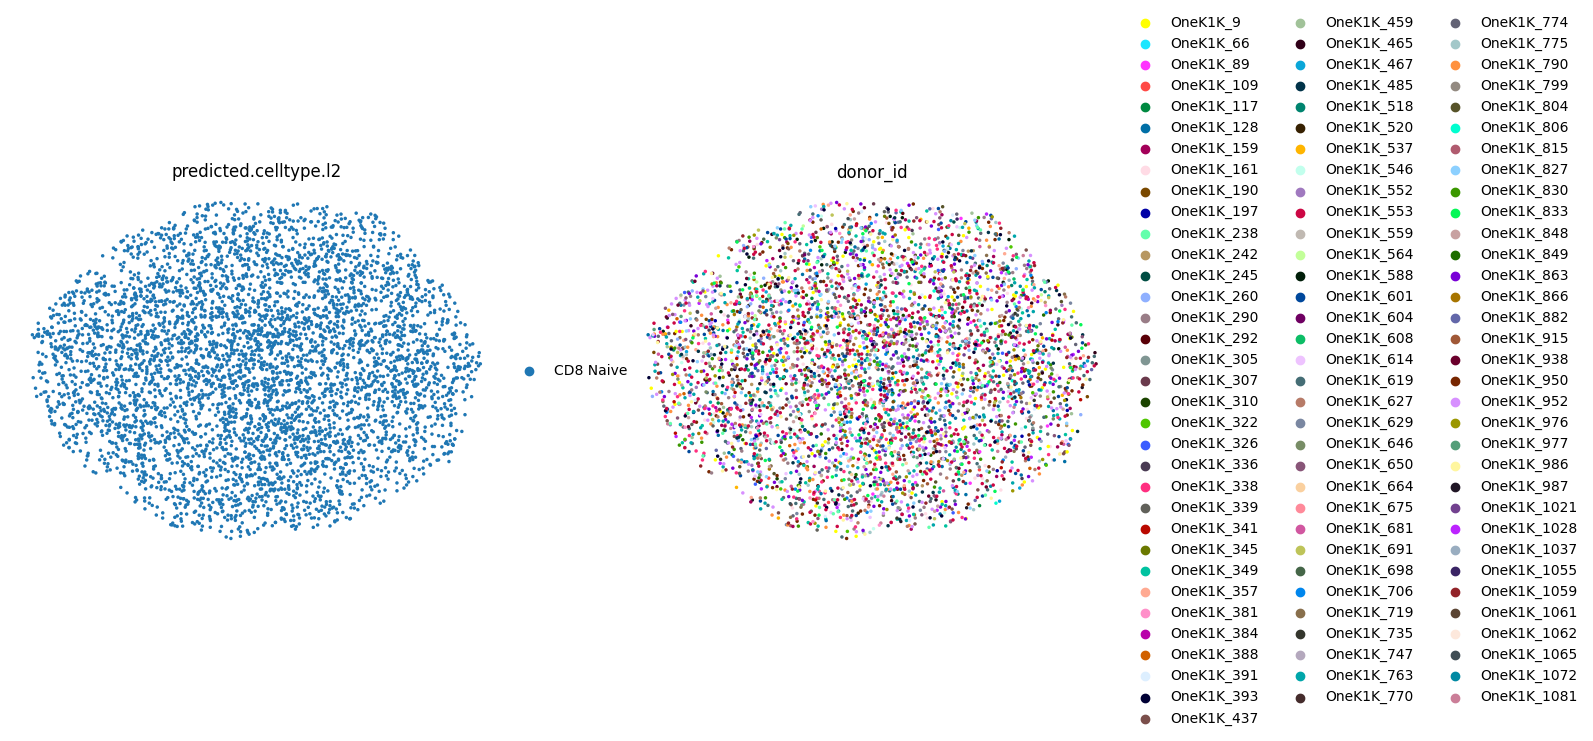

In [26]:
# Add cell-state factors to adata as an obsm embedding
dd_ct.C.obsm["X_livi"] = cell_state.loc[dd_ct.C.obs_names].values

# Compute neighbours and UMAP from LIVI factors
sc.pp.neighbors(dd_ct.C, use_rep="X_livi", n_neighbors=15)
sc.tl.umap(dd_ct.C)
sc.pl.umap(dd_ct.C, color=[celltype_key, "donor_id"], frameon=False)

### Donor Embeddings

The **D embedding** captures how each donor's gene expression is modulated by their cell state. Each row is a donor; each column is a learned DxC interaction factor.

In [27]:
D_embedding = results["D_embedding"]
print(f"D embedding (donor × DxC): {D_embedding.shape}")
D_embedding.head()

D embedding (donor × DxC): (100, 20)


,D_Factor1,D_Factor2,D_Factor3,D_Factor4,D_Factor5,D_Factor6,D_Factor7,D_Factor8,D_Factor9,D_Factor10,D_Factor11,D_Factor12,D_Factor13,D_Factor14,D_Factor15,D_Factor16,D_Factor17,D_Factor18,D_Factor19,D_Factor20
OneK1K_806,-1.034603,1.239414,1.027150,-1.015963,1.078983,-0.922727,0.303131,0.433731,-1.274470,-0.344438,0.749071,-0.352727,1.331107,-0.639199,-0.325714,-0.845799,-0.255283,-1.680578,-0.403255,0.551376
OneK1K_518,-1.981410,1.104749,0.332198,-1.778168,0.808574,0.264368,-1.387855,1.445571,-1.555081,-0.061444,0.320580,0.195985,-0.451888,0.510993,0.578600,0.682118,1.674435,0.067651,-0.496550,0.825534
OneK1K_161,1.586433,-0.925274,0.231036,-0.124887,-0.593605,-0.251016,-0.120468,-0.978208,1.103788,0.091734,0.757912,-0.177333,0.972607,0.353099,0.127957,-0.061490,1.059204,0.010201,-2.203331,0.417635
OneK1K_588,-0.006535,1.101780,-0.249835,-0.312075,0.775569,1.961142,-1.121343,-0.887146,-0.255658,-1.463809,0.997576,-1.572812,0.764885,0.853866,-1.896944,-0.731113,1.097427,-0.848530,0.085140,1.636604
OneK1K_1061,0.168279,-0.273804,-0.369246,1.355094,0.614525,-0.163213,0.964817,0.039061,0.877973,-1.452540,1.360181,0.172289,0.565182,1.011555,-0.944389,-1.349483,0.266966,-1.038685,-0.432639,-0.313990


The `variance_threshold` argument retains only D factors with sufficient variability across donors, reducing noise in downstream association testing.

In [28]:
results_filtered = infer_livi(
    dd_ct,
    checkpoint_path=checkpoint_path,
    variance_threshold=0.01,  # keep only variable D factors
)

print("All D factors:     ", results["D_embedding"].shape)
print("Variable D factors:", results_filtered["D_embedding"].shape)

[2026-05-21 14:12:51,205] INFO:cellink.tl.external._livi: Loading LIVI checkpoint: /Users/selman/projects/cellink/docs/tutorials/livi_basic_run/checkpoints/epoch=0005_hp_metric=13243.94531.ckpt
All D factors:      (100, 20)
Variable D factors: (100, 20)


## Association Testing: Linking Donor Embeddings to Genotype

LIVI's donor embeddings can be treated as quantitative traits and tested for association with genetic variants. `run_livi_association_testing` tests each D and V factor against all SNPs using either:

- `"LMM"` (LIMIX): a linear mixed model that accounts for sample relatedness via a kinship matrix — recommended for cohorts with population structure.
- `"TensorQTL"`: fast GPU-accelerated testing without relatedness correction.

**When a `DonorData` object is passed as `genotype_matrix`, the wrapper automatically extracts:**
- `dd.G.X` → donors × SNPs genotype matrix
- `dd.G.uns["kinship"]` → kinship / GRM matrix (used for `method="LMM"`)
- `dd.G.obsm["gPCs"]` → genotype PCs (used as covariates)

You can always override any of these by passing `kinship=` or `genotype_pcs=` explicitly.

In [29]:
# Pass DonorData directly — dd.G.X, dd.G.uns["kinship"], and dd.G.obsm["gPCs"]
# are all extracted automatically.
associations = run_livi_association_testing(
    inference_results=results,
    genotype_matrix=dd,          # DonorData: dd.G is used for genotypes + kinship + gPCs
    output_dir="livi_associations",
    method="LMM",
    fdr_threshold=0.05,
    fdr_method="Benjamini-Hochberg",
    quantile_norm=True,
    output_file_prefix="demo",
)

# Returns a tuple (DxC_results, V_results) when both D and V embeddings are present
DxC_assoc, V_assoc = associations if isinstance(associations, tuple) else (associations, None)
print(f"DxC associations: {DxC_assoc.shape if DxC_assoc is not None else 'None'}")
print(f"V associations:   {V_assoc.shape if V_assoc is not None else 'None'}")

ModuleNotFoundError: No module named 'pyrootutils'

In [ ]:
if DxC_assoc is not None:
    DxC_assoc.head()

### Explicit Component Override

When you need more control — e.g. a subset of SNPs or a different kinship — you can pass components individually instead of using `DonorData`. All three (genotype matrix, kinship, genotype PCs) can be overridden independently while still passing `dd` for the rest.

In [ ]:
# Example: override genotype PCs but still pass dd for genotype matrix and kinship
# gPCs = dd.G.obsm["gPCs"]   # already extracted automatically when passing dd,
#                              # but you could subset or replace it here

# --- TensorQTL: pass components explicitly (no kinship needed) ---
#
# from anndata.utils import asarray
# GT_matrix = pd.DataFrame(
#     asarray(dd.G.X), index=dd.G.obs_names, columns=dd.G.var_names
# )
# gPCs = dd.G.obsm["gPCs"]
#
# associations_tensorqtl = run_livi_association_testing(
#     inference_results=results,
#     genotype_matrix=GT_matrix,   # explicit DataFrame
#     output_dir="livi_associations_tensorqtl",
#     method="TensorQTL",
#     genotype_pcs=gPCs,
#     fdr_threshold=0.05,
#     quantile_norm=True,
# )

## Saving and Loading Results

`save_livi_results` writes all inference DataFrames to TSV files in a single directory. `load_livi_results` reads them back, allowing you to restart downstream analyses without re-running inference.

In [ ]:
# Save
saved_paths = save_livi_results(
    results,
    output_dir="livi_results",
    prefix="cd8_naive",
)
print("Saved files:")
for key, path in saved_paths.items():
    print(f"  {key}: {path}")

[2026-05-19 04:32:58,752] INFO:cellink.tl.external._livi: Saved cell_state_latent → livi_results/cd8_naive_cell_state_latent.tsv
[2026-05-19 04:32:58,836] INFO:cellink.tl.external._livi: Saved cell_state_decoder → livi_results/cd8_naive_cell_state_decoder.tsv
[2026-05-19 04:32:58,857] INFO:cellink.tl.external._livi: Saved D_embedding → livi_results/cd8_naive_D_embedding.tsv
[2026-05-19 04:32:59,181] INFO:cellink.tl.external._livi: Saved DxC_decoder → livi_results/cd8_naive_DxC_decoder.tsv
[2026-05-19 04:32:59,191] INFO:cellink.tl.external._livi: Saved assignment_matrix → livi_results/cd8_naive_assignment_matrix.tsv
[2026-05-19 04:32:59,287] INFO:cellink.tl.external._livi: Saved V_embedding → livi_results/cd8_naive_V_embedding.tsv
[2026-05-19 04:32:59,358] INFO:cellink.tl.external._livi: Saved V_decoder → livi_results/cd8_naive_V_decoder.tsv
Saved files:
  cell_state_latent: livi_results/cd8_naive_cell_state_latent.tsv
  cell_state_decoder: livi_results/cd8_naive_cell_state_decoder.tsv


In [ ]:
# Load back
results_loaded = load_livi_results("livi_results", prefix="cd8_naive")
print("Loaded DataFrames:", list(results_loaded.keys()))

Loaded DataFrames: ['cell_state_latent', 'cell_state_decoder', 'D_embedding', 'DxC_decoder', 'V_embedding', 'V_decoder', 'assignment_matrix']
